# 99_analyze_4regime — 4-레짐 분석 (hold-out 없이 전체 192m)

99_analyze.ipynb의 K_CUT을 제거하고 **2010-01 ~ 2025-12 (192개월) 전체기간**을 사용해 4개 레짐으로 분해.

## 4-레짐 정의

| 레짐 | 기간 | 개월수 | 환경 |
|---|---|:---:|---|
| **R1 회복** | 2010-01-01 ~ 2012-06-30 | 30 | Post-GFC + EU 위기 |
| **R2 확장** | 2012-07-01 ~ 2019-12-31 | 90 | 장기 Bull |
| **R3 변동** | 2020-01-01 ~ 2023-06-30 | 42 | COVID + '22 베어 |
| **R4 AI랠리** | 2023-07-01 ~ 2025-12-31 | 30 | AI 강세장 (평가 기간 짧음 ⚠️) |

**총 192개월** (R1+R2+R3+R4 = 30+90+42+30).

> ⚠️ R4는 30개월(2.5년)로 다른 레짐 대비 짧음. sortino_R4 단독값은 변동 클 수 있고, sortino_ir(mean/std) 계산 시 R4의 outlier 효과 큼.

## 시각화 구조
1. master/regime table 빌드 (4-레짐)
2. **sortino_full Top 20 히트맵** (4-레짐 × 3 metric)
3. **sortino_ir Top 20 히트맵**
4. Top 50 교집합 후보 분석


In [7]:
# ── 데이터 로드 (K_CUT 없음, 전체 192m) ─────────────────────
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import platform
from pathlib import Path

warnings.filterwarnings('ignore')

if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'Arial Unicode MS', 'DejaVu Sans']
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'Arial Unicode MS', 'DejaVu Sans']
else:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'Noto Sans CJK KR', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

RESULTS_DIR = Path.cwd() / 'results'
OUT_DIR = Path.cwd() / 'outputs' / '99_analyze_4regime'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# rf 로드
panel_rf = pd.read_csv(Path.cwd() / 'data' / 'monthly_panel.csv',
                       usecols=['date','ticker','rf_1m'], parse_dates=['date'])
rf = panel_rf.groupby('date')['rf_1m'].first()

# spy_ret (baseline pkl에서)
with open(RESULTS_DIR / 'baseline.pkl', 'rb') as f:
    spy_ret = pickle.load(f)['spy_ret'].dropna()

print(f'rf 기간      : {rf.index.min().date()} ~ {rf.index.max().date()}')
print(f'spy_ret 기간 : {spy_ret.index.min().date()} ~ {spy_ret.index.max().date()} ({len(spy_ret)}m)')
print(f'pkl 개수     : {len(list(RESULTS_DIR.glob("*.pkl")))}')


rf 기간      : 2005-01-31 ~ 2025-12-31
spy_ret 기간 : 2010-01-31 ~ 2025-11-30 (190m)
pkl 개수     : 183


## 4-레짐 정의 + master/regime table 빌드

In [8]:
# ── 4-레짐 정의 (hold-out 없음, 전체 192m 분해) ──────────────
REGIMES_4 = [
    ('R1_회복',   '2010-01-01', '2012-06-30'),  # 30m
    ('R2_확장',   '2012-07-01', '2019-12-31'),  # 90m
    ('R3_변동',   '2020-01-01', '2023-06-30'),  # 42m
    ('R4_AI랠리', '2023-07-01', '2025-12-31'),  # 30m (평가 기간 짧음)
]
REGIME_LABELS_4 = [r[0] for r in REGIMES_4]
PERIODS_4 = {label: (s, e) for label, s, e in REGIMES_4}

print('4-레짐 정의:')
for lbl, s, e in REGIMES_4:
    n = pd.date_range(s, e, freq='ME').size
    print(f'  {lbl:<10}  {s} ~ {e}  ({n}m)')

# build_master_table / build_regime_table 호출 (커스텀 레짐 사용)
from master_table import build_master_table, build_regime_table

mt_full = build_master_table(RESULTS_DIR, rf, spy_ret, periods=PERIODS_4)
# 분석에서 sensitivity sweep + winner_* 변형 제외
mask = (
    mt_full['name'].str.endswith(('_q55','_q64','_q70')) |
    mt_full['name'].str.startswith('winner_')
)
mt = mt_full[~mask].copy()
print(f'\nmt: {len(mt_full)}개 → 필터 후 {len(mt)}개 (sensitivity 변형 제외)')

rt_full = build_regime_table(mt_full, RESULTS_DIR, rf, regimes=REGIMES_4)
rt = rt_full[~mask].copy()
print(f'rt: {len(rt_full)}개 → 필터 후 {len(rt)}개')
print(f'rt columns ({len(rt.columns)}개): {[c for c in rt.columns if any(r in c for r in ["R1","R2","R3","R4","sortino_","sharpe_","mdd_"])][:25]} ...')

# rt에 전체기간 sortino를 sortino_full로 병합 (sortino_ir과 별개로 정렬용)
rt = rt.merge(mt[['name','sortino']].rename(columns={'sortino':'sortino_full'}),
              on='name', how='left')
print(f'\nsortino_full 포함 rt 준비 완료')
# rt에 전체기간 sharpe도 sharpe_full로 병합 (sortino_full과 일관)
rt = rt.merge(mt[['name','sharpe']].rename(columns={'sharpe':'sharpe_full'}),
              on='name', how='left')
print('sharpe_full 포함 rt 준비 완료')


4-레짐 정의:
  R1_회복       2010-01-01 ~ 2012-06-30  (30m)
  R2_확장       2012-07-01 ~ 2019-12-31  (90m)
  R3_변동       2020-01-01 ~ 2023-06-30  (42m)
  R4_AI랠리     2023-07-01 ~ 2025-12-31  (30m)

mt: 183개 → 필터 후 163개 (sensitivity 변형 제외)
rt: 183개 → 필터 후 163개
rt columns (60개): ['sortino_TEST', 'sortino_HOLD_OUT', 'sortino_FULL', 'sharpe_TEST', 'sharpe_HOLD_OUT', 'sharpe_FULL', 'mdd_duration', 'sharpe_R1_회복', 'sharpe_R2_확장', 'sharpe_R3_변동', 'sharpe_R4_AI랠리', 'mdd_TEST', 'mdd_HOLD_OUT', 'mdd_FULL', 'sortino_R1_회복', 'mdd_R1_회복', 'sortino_R2_확장', 'mdd_R2_확장', 'sortino_R3_변동', 'mdd_R3_변동', 'sortino_R4_AI랠리', 'mdd_R4_AI랠리', 'sortino_mean', 'sortino_std', 'sharpe_mean'] ...

sortino_full 포함 rt 준비 완료
sharpe_full 포함 rt 준비 완료


## A. sortino_full Top 20 히트맵 (4-레짐)

전체기간(192m) Sortino 단순 max로 Top 20 후보 추출 → 4-레짐 × 3-metric 격자로 안정성 점검.

=== A. sortino_full 정렬 Top 20 (4-레짐 × 3 metric 히트맵) ===
  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨

■ Top 20 행 매핑 (sortino_full 큰 순)


,canonical,sortino_full,sortino_mean,sortino_std,sortino_ir,mdd_worst
1,mcap_tr_mcap_raw_pap,2.064,2.207,0.879,2.51,-0.140
2,mcap_tr_mcap_lam_pap,1.965,2.147,0.904,2.37,-0.140
3,mcap_ls_mcap_raw_rms,1.877,1.765,0.304,5.81,-0.133
4,mcap_tr_mcap_raw_he,1.875,1.704,0.471,3.62,-0.123
5,eq_ls_eq_raw_pap,1.862,1.799,0.647,2.78,-0.129
6,rp_ls_eq_raw_pap,1.860,1.822,0.773,2.36,-0.129
7,eq_ls_mcap_raw_rms,1.857,1.772,0.603,2.94,-0.139
8,mcap_ls_mcap_raw_he,1.855,1.729,0.273,6.33,-0.136
9,mcap_ls_eq_raw_pap,1.853,1.786,0.396,4.51,-0.139
10,eq_ls_eq_lam_pap,1.850,1.760,0.626,2.81,-0.129


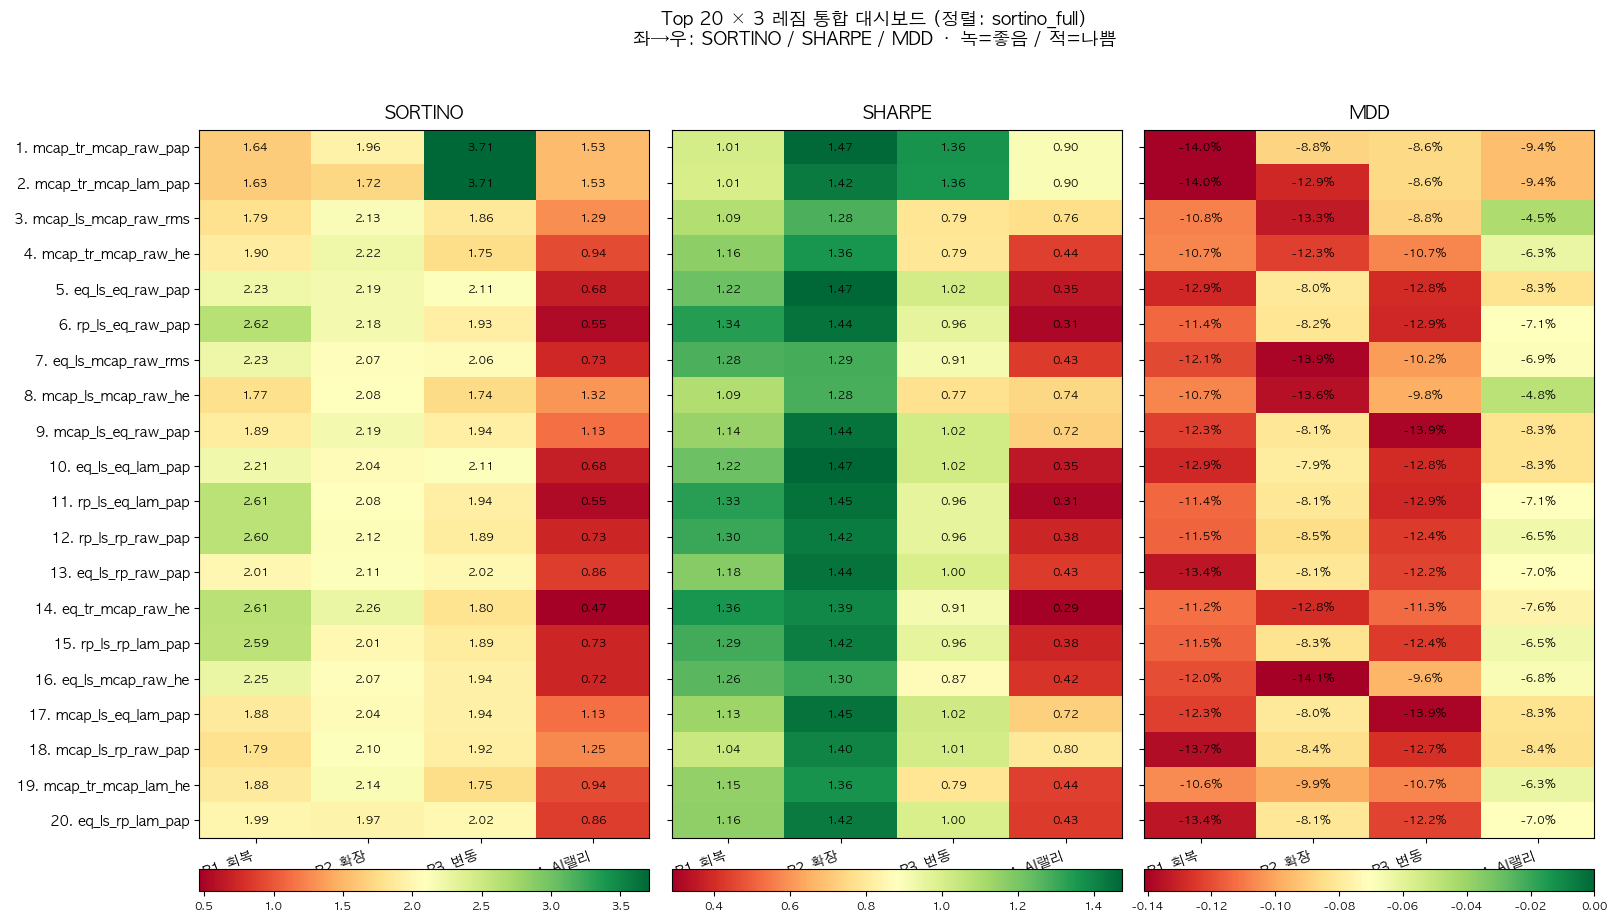

In [9]:
# ── A. sortino_full Top 20 dashboard (4-레짐) ─────────────
import importlib, analyze_plots
importlib.reload(analyze_plots)
from analyze_plots import plot_styled_regime_dashboard

print('=== A. sortino_full 정렬 Top 20 (4-레짐 × 3 metric 히트맵) ===')
print('  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨')

_ = plot_styled_regime_dashboard(
    rt, rank_by='sortino_full', top_n=20,
    regime_labels=REGIME_LABELS_4,
    save_path=OUT_DIR / 'A_sortino_full_dashboard.png',
)

top20_sf = rt.nlargest(20, 'sortino_full').reset_index(drop=True); top20_sf.index += 1
print('\n■ Top 20 행 매핑 (sortino_full 큰 순)')
display(top20_sf[['canonical','sortino_full','sortino_mean','sortino_std','sortino_ir','mdd_worst']].round(3))


## B. sortino_ir Top 20 히트맵 (4-레짐)

레짐별 Sortino의 mean/std (= sortino_ir) 기준 Top 20 — 4 레짐 모두에서 일관되게 강한 후보.

=== B. sortino_ir 정렬 Top 20 (4-레짐 × 3 metric 히트맵) ===
  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨

■ Top 20 행 매핑 (sortino_ir 큰 순)


,canonical,sortino_ir,sortino_mean,sortino_std,sortino_full,mdd_worst
1,mcap_tr_mcap_fix_rms,10.94,1.729,0.158,1.727,-0.122
2,mcap_ls_rp_vsp_pap,8.79,1.688,0.192,1.650,-0.133
3,mcap_ls_mcap_fix_he,8.65,1.575,0.182,1.518,-0.123
4,mcap_ls_mcap_fix_rms,8.61,1.558,0.181,1.535,-0.114
5,mcap_tr_mcap_inv_pap,8.04,1.544,0.192,1.477,-0.162
6,mcap_ls_rp_fix_pap,7.50,1.711,0.228,1.651,-0.135
7,mcap_ls_mcap_lam_he,7.46,1.678,0.225,1.761,-0.113
8,mcap_ls_mcap_vsp_rms,7.18,1.537,0.214,1.512,-0.115
9,mcap_ls_mcap_lam_rms,7.05,1.693,0.240,1.755,-0.121
10,mcap_ls_mcap_vsp_he,7.03,1.554,0.221,1.505,-0.123


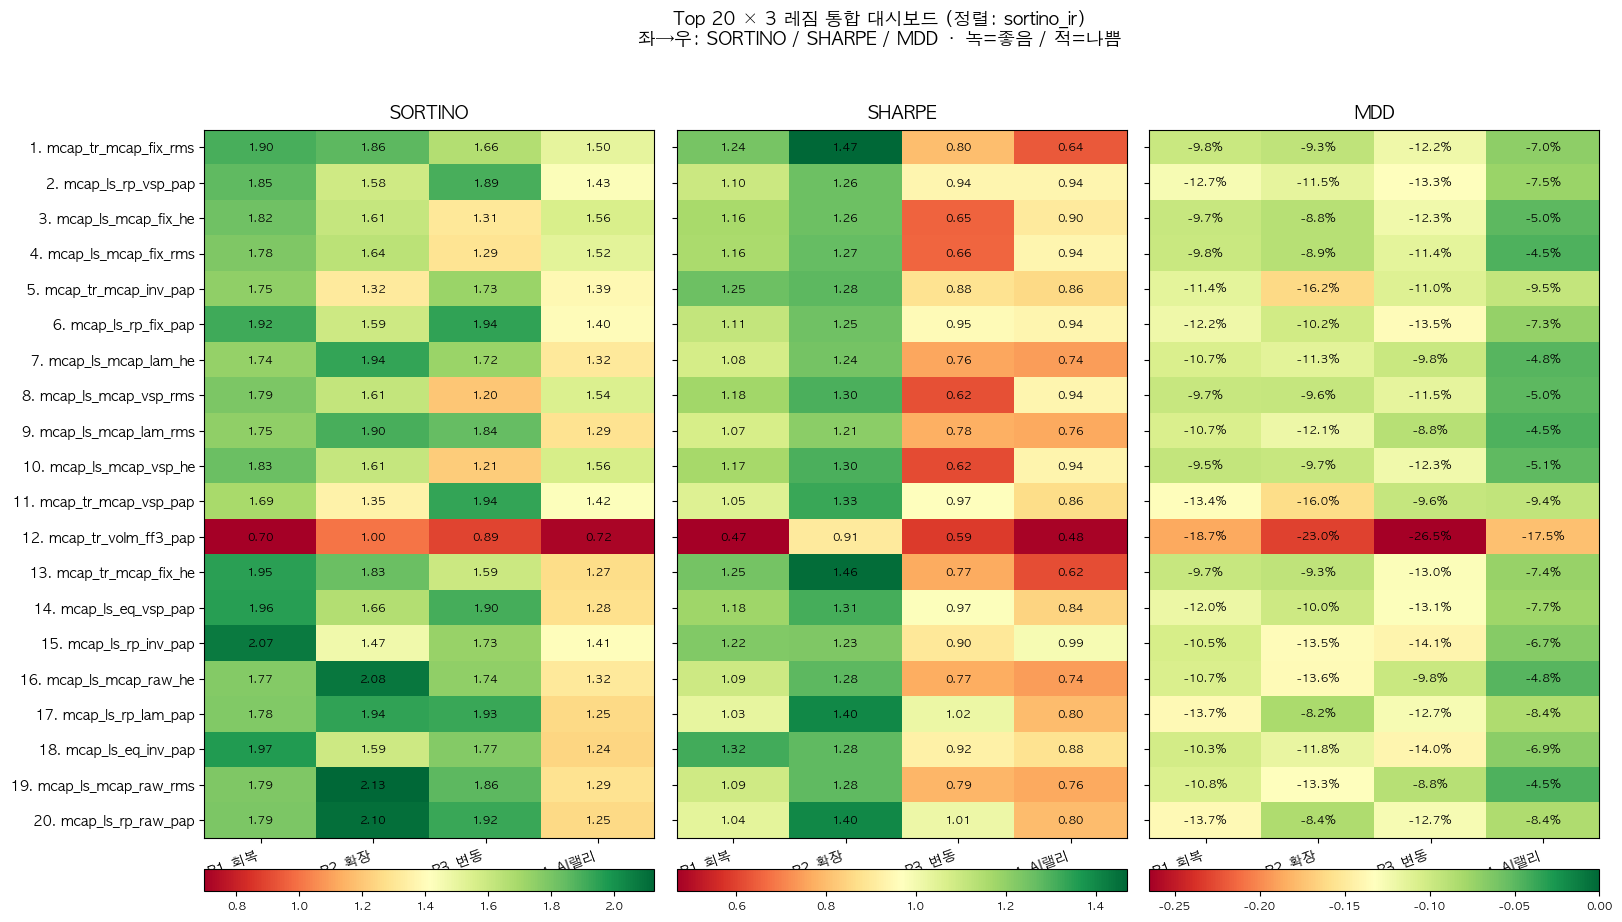

In [10]:
# ── B. sortino_ir Top 20 dashboard (4-레짐) ────────────────
print('=== B. sortino_ir 정렬 Top 20 (4-레짐 × 3 metric 히트맵) ===')
print('  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨')

_ = plot_styled_regime_dashboard(
    rt, rank_by='sortino_ir', top_n=20,
    regime_labels=REGIME_LABELS_4,
    save_path=OUT_DIR / 'B_sortino_ir_dashboard.png',
)

top20_si = rt.nlargest(20, 'sortino_ir').reset_index(drop=True); top20_si.index += 1
print('\n■ Top 20 행 매핑 (sortino_ir 큰 순)')
display(top20_si[['canonical','sortino_ir','sortino_mean','sortino_std','sortino_full','mdd_worst']].round(3))


## C. Sortino IR ∩ sortino_full Top 50 교집합 후보 (4-레짐)

K2-X50와 동일 로직 — 두 측면 모두 강한 robust 후보.

■ 4-레짐 교집합 (sortino_full Top50 ∩ sortino_ir Top50): 12개
  · sortino_full만 Top50: 38개
  · sortino_ir만 Top50  : 38개

=== C-1. 교집합 12개 — 4-레짐 × 3 metric 히트맵 (sortino_full 정렬) ===

■ 교집합 행 매핑 (sortino_full 큰 순)


,canonical,sortino_full,sortino_ir,sortino_mean,sortino_std,mdd_worst
1,mcap_ls_mcap_raw_rms,1.877,5.81,1.765,0.304,-0.133
2,mcap_tr_mcap_raw_he,1.875,3.62,1.704,0.471,-0.123
3,mcap_ls_mcap_raw_he,1.855,6.33,1.729,0.273,-0.136
4,mcap_ls_eq_raw_pap,1.853,4.51,1.786,0.396,-0.139
5,mcap_ls_eq_lam_pap,1.819,4.82,1.746,0.362,-0.139
6,mcap_ls_rp_raw_pap,1.818,5.57,1.767,0.317,-0.137
7,mcap_tr_mcap_lam_he,1.818,3.75,1.678,0.447,-0.107
8,mcap_ls_rp_lam_pap,1.787,6.16,1.725,0.280,-0.137
9,mcap_ls_mcap_lam_he,1.761,7.46,1.678,0.225,-0.113
10,mcap_ls_mcap_lam_rms,1.755,7.05,1.693,0.240,-0.121



=== C-2. 교집합 12개 — 전체기간 메트릭 표 ===
pkl                             canonical                         Sharpe  Sortino    CAGR     변동성      MDD    Beta   Alpha
----------------------------------------------------------------------------------------------------------------------------
mat_mcap_mcap_raw_rms           mcap_ls_mcap_raw_rms               1.044    1.877  13.13%  11.14%  -13.33%   0.503   4.83%
q_raw_lam                       mcap_tr_mcap_raw_he                1.037    1.875  12.89%  10.97%  -12.69%   0.513   4.51%
mat_mcap_mcap_raw_he            mcap_ls_mcap_raw_he                1.040    1.855  13.11%  11.17%  -13.60%   0.514   4.68%
mat_mcap_eq_raw_pap             mcap_ls_eq_raw_pap                 1.150    1.853  16.23%  12.66%  -13.90%   0.711   5.19%
mat_mcap_eq_lam_pap             mcap_ls_eq_lam_pap                 1.156    1.819  16.42%  12.76%  -13.90%   0.720   5.25%
mat_mcap_rp_raw_pap             mcap_ls_rp_raw_pap                 1.125    1.818  15.79%  12.60%  -13

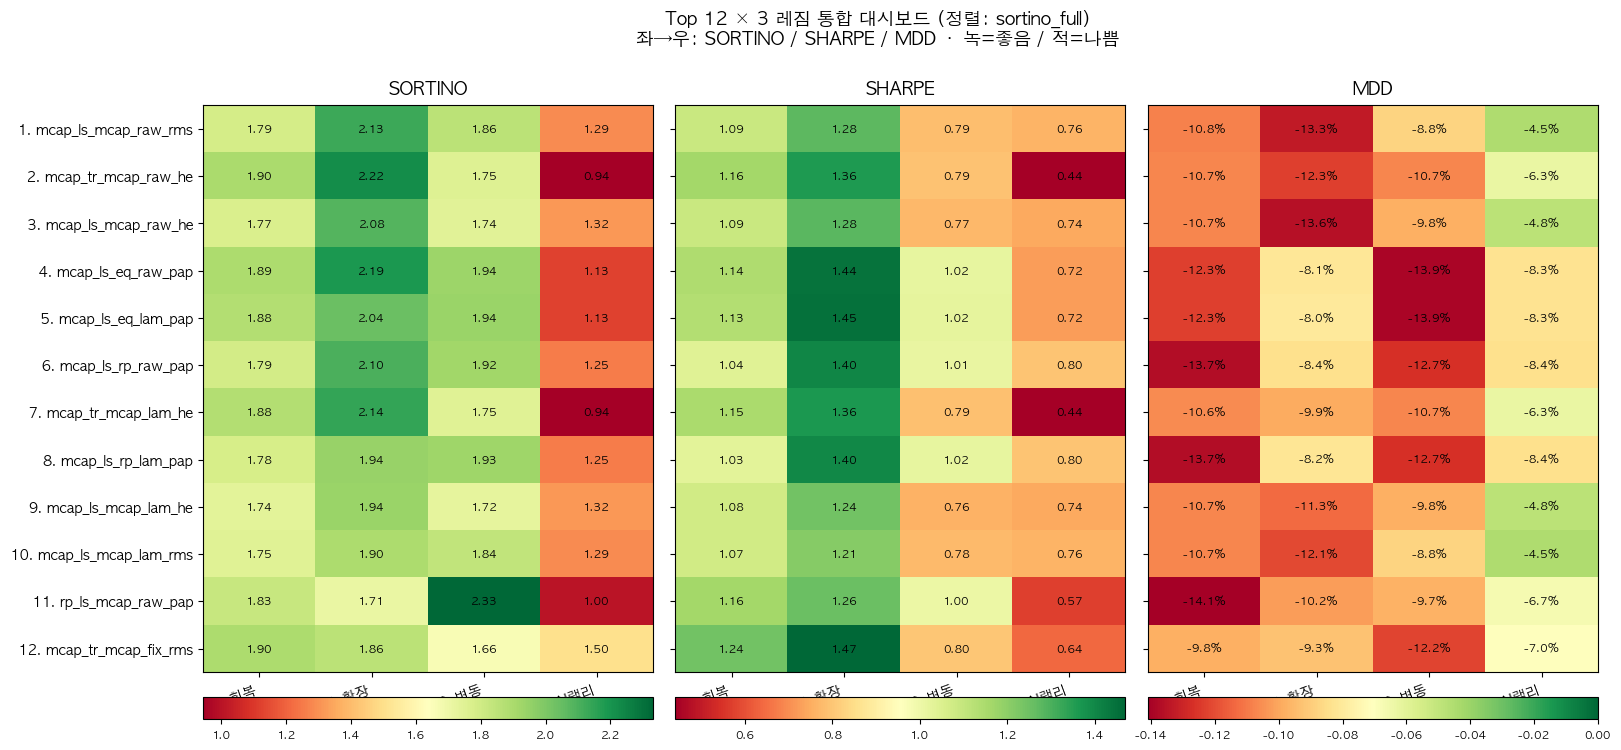

In [11]:
# ── C. Top 50 교집합 (4-레짐 기준) ──────────────────────────
N = 50
top50_sf_names = set(rt.nlargest(N, 'sortino_full')['name'])
top50_si_names = set(rt.nlargest(N, 'sortino_ir')['name'])
inter = top50_sf_names & top50_si_names

print(f'■ 4-레짐 교집합 (sortino_full Top{N} ∩ sortino_ir Top{N}): {len(inter)}개')
print(f'  · sortino_full만 Top{N}: {len(top50_sf_names - top50_si_names)}개')
print(f'  · sortino_ir만 Top{N}  : {len(top50_si_names - top50_sf_names)}개')

if len(inter) > 0:
    # 교집합 후보만 sortino_full 내림차순으로 dashboard
    rt_inter = rt[rt['name'].isin(inter)].copy()
    print(f'\n=== C-1. 교집합 {len(inter)}개 — 4-레짐 × 3 metric 히트맵 (sortino_full 정렬) ===')
    _ = plot_styled_regime_dashboard(
        rt_inter, rank_by='sortino_full', top_n=len(inter),
        regime_labels=REGIME_LABELS_4,
        save_path=OUT_DIR / 'C1_intersection_dashboard.png',
    )

    # 행 매핑
    inter_top = rt_inter.nlargest(len(inter), 'sortino_full').reset_index(drop=True); inter_top.index += 1
    print(f'\n■ 교집합 행 매핑 (sortino_full 큰 순)')
    display(inter_top[['canonical','sortino_full','sortino_ir','sortino_mean','sortino_std','mdd_worst']].round(3))

    # 전체기간 메트릭 표
    print(f'\n=== C-2. 교집합 {len(inter)}개 — 전체기간 메트릭 표 ===')
    inter_ordered = rt_inter.nlargest(len(inter), 'sortino_full')['name'].tolist()
    summary = mt[mt['name'].isin(inter_ordered)].copy()
    summary['_order'] = summary['name'].map({n:i for i,n in enumerate(inter_ordered)})
    summary = summary.sort_values('_order').drop(columns='_order')

    header = '=' * 124
    sep    = '-' * 124
    print(header)
    print(f'{"pkl":<32}{"canonical":<32}{"Sharpe":>8}{"Sortino":>9}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
    print(sep)
    for _, r in summary.iterrows():
        print(f'{r["name"][:31]:<32}{str(r["canonical"])[:31]:<32}'
              f'{r["sharpe"]:>8.3f}{r["sortino"]:>9.3f}'
              f'{r["cagr"]*100:>7.2f}%{r["vol"]*100:>7.2f}%{r["mdd"]*100:>8.2f}%'
              f'{(f"{r["beta"]:.3f}" if pd.notna(r["beta"]) else "-"):>8}'
              f'{(f"{r["alpha"]*100:.2f}%" if pd.notna(r["alpha"]) else "-"):>8}')
    print(header)

    # 슬롯 분포
    print(f'\n=== C-3. 교집합 {len(inter)}개 슬롯 분포 ===')
    for slot in ['prior_s','p_s','pw_s','q_s','om_s']:
        if slot in summary.columns:
            vc = summary[slot].value_counts()
            print(f'  [{slot}] ' + ' / '.join(f'{k}={v}' for k,v in vc.items()))


## D. 3-레짐 vs 4-레짐 winner 변화 점검

기존 K2-X50 (3-레짐 + K_CUT 2023-12) winner와 비교해 어떤 후보가 R4(AI랠리)에서 견뎌서 살아남는지 확인.

In [12]:
# ── D. winner 후보 변화 분석 ─────────────────────────────
WINNER_3R = 'mat_eq_eq_lam_pap'   # 기존 3-레짐 K2-X50 composite 1위
print(f'■ 3-레짐 winner ({WINNER_3R}) 의 4-레짐에서 위치')
w3r = rt[rt['name']==WINNER_3R]
if len(w3r) > 0:
    w = w3r.iloc[0]
    sf_rank = (rt['sortino_full'] > w['sortino_full']).sum() + 1
    si_rank = (rt['sortino_ir']   > w['sortino_ir']).sum()   + 1
    in_inter = w['name'] in inter
    print(f'  sortino_full = {w["sortino_full"]:.3f} (rank {sf_rank}/{len(rt)})')
    print(f'  sortino_ir   = {w["sortino_ir"]:.3f} (rank {si_rank}/{len(rt)})')
    print(f'  4-레짐 교집합 멤버? {"✓" if in_inter else "❌"}')
    print(f'\n  4-레짐별 sortino:')
    for lbl in REGIME_LABELS_4:
        col = f'sortino_{lbl}'
        if col in w.index:
            print(f'    {lbl:<12}  {w[col]:.3f}')

# 4-레짐 composite Top 5
print('\n\n■ 4-레짐 composite Top 5 (so_full + so_ir + mdd_worst rank 평균)')
df_c = rt.copy()
df_c['rk_sf']  = df_c['sortino_full'].rank(ascending=False)
df_c['rk_si']  = df_c['sortino_ir'].rank(ascending=False)
df_c['rk_mdd'] = df_c['mdd_worst'].rank(ascending=False)
df_c['composite'] = df_c[['rk_sf','rk_si','rk_mdd']].mean(axis=1)
top5_c = df_c.nsmallest(5, 'composite')[['name','canonical','sortino_full','sortino_ir','mdd_worst','composite']]
display(top5_c.round(3))


■ 3-레짐 winner (mat_eq_eq_lam_pap) 의 4-레짐에서 위치
  sortino_full = 1.850 (rank 10/163)
  sortino_ir   = 2.810 (rank 83/163)
  4-레짐 교집합 멤버? ❌

  4-레짐별 sortino:
    R1_회복         2.205
    R2_확장         2.044
    R3_변동         2.108
    R4_AI랠리       0.680


■ 4-레짐 composite Top 5 (so_full + so_ir + mdd_worst rank 평균)


,name,canonical,sortino_full,sortino_ir,mdd_worst,composite
27,mat_mcap_mcap_lam_he,mcap_ls_mcap_lam_he,1.761,7.46,-0.113,16.833
18,q_lambda,mcap_tr_mcap_lam_he,1.818,3.75,-0.107,23.167
30,mat_mcap_mcap_lam_rms,mcap_ls_mcap_lam_rms,1.755,7.05,-0.121,28.667
36,omega_rmse,mcap_tr_mcap_fix_rms,1.727,10.94,-0.122,29.667
3,q_raw_lam,mcap_tr_mcap_raw_he,1.875,3.62,-0.123,36.833


## E. sharpe_full Top 20 히트맵 (4-레짐)

전체기간(192m) Sharpe 단순 max로 Top 20 후보 추출 → 4-레짐 × 3-metric 격자.
sortino와 다른 정렬이 나오는지 비교.

=== E. sharpe_full 정렬 Top 20 (4-레짐 × 3 metric 히트맵) ===
  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨

■ Top 20 행 매핑 (sharpe_full 큰 순)


,canonical,sharpe_full,sharpe_mean,sharpe_std,sharpe_ir,sortino_full,mdd_worst
1,mcap_tr_mcap_raw_pap,1.244,1.186,0.237,5.00,2.064,-0.140
2,mcap_tr_mcap_lam_pap,1.233,1.173,0.224,5.24,1.965,-0.140
3,mcap_ls_eq_lam_pap,1.156,1.082,0.258,4.19,1.819,-0.139
4,mcap_ls_eq_raw_pap,1.150,1.082,0.257,4.21,1.853,-0.139
5,mcap_ls_rp_lam_pap,1.130,1.062,0.217,4.89,1.787,-0.137
6,mcap_ls_eq_fix_pap,1.127,1.084,0.192,5.65,1.688,-0.130
7,mcap_ls_rp_raw_pap,1.125,1.063,0.217,4.90,1.818,-0.137
8,mcap_tr_mcap_fix_pap,1.121,1.079,0.166,6.50,1.617,-0.157
9,mcap_ls_eq_vsp_pap,1.113,1.077,0.180,5.98,1.680,-0.131
10,mcap_ls_eq_inv_pap,1.113,1.099,0.198,5.55,1.614,-0.140


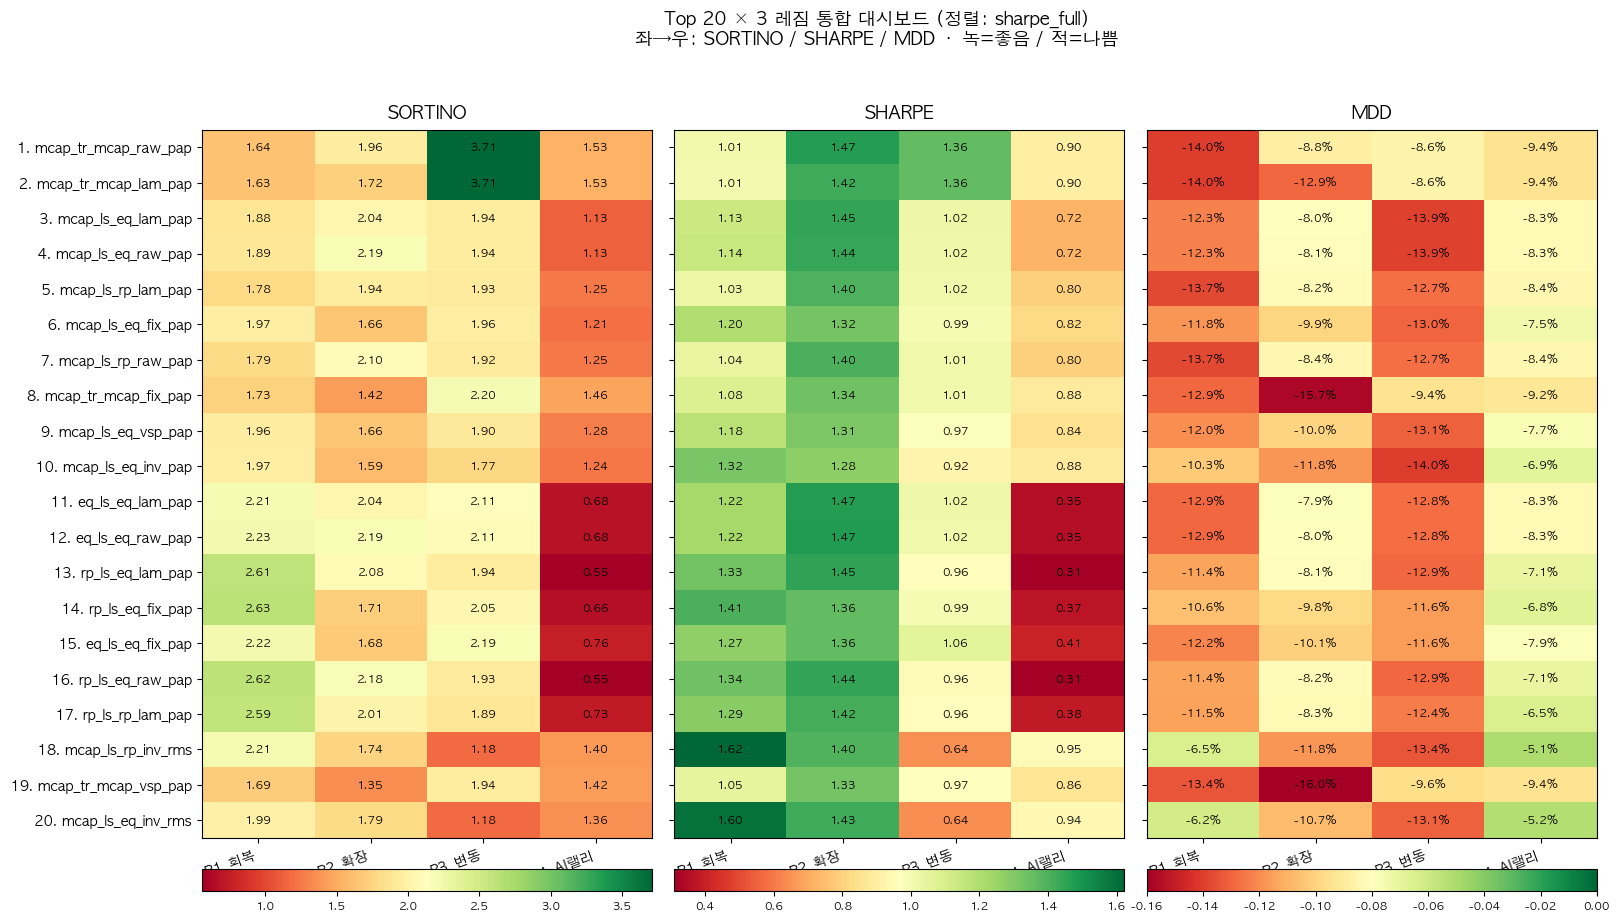

In [13]:
# ── E. sharpe_full Top 20 dashboard (4-레짐) ─────────────
print('=== E. sharpe_full 정렬 Top 20 (4-레짐 × 3 metric 히트맵) ===')
print('  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨')

_ = plot_styled_regime_dashboard(
    rt, rank_by='sharpe_full', top_n=20,
    regime_labels=REGIME_LABELS_4,
    save_path=OUT_DIR / 'E_sharpe_full_dashboard.png',
)

top20_shf = rt.nlargest(20, 'sharpe_full').reset_index(drop=True); top20_shf.index += 1
print('\n■ Top 20 행 매핑 (sharpe_full 큰 순)')
display(top20_shf[['canonical','sharpe_full','sharpe_mean','sharpe_std','sharpe_ir','sortino_full','mdd_worst']].round(3))


## F. sharpe_ir Top 20 히트맵 (4-레짐)

레짐별 Sharpe의 mean/std (= sharpe_ir) 기준 — 4 레짐 모두에서 일관되게 강한 후보.
sortino_ir과 다른 후보가 잡히는지 비교.

=== F. sharpe_ir 정렬 Top 20 (4-레짐 × 3 metric 히트맵) ===
  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨

■ Top 20 행 매핑 (sharpe_ir 큰 순)


,canonical,sharpe_ir,sharpe_mean,sharpe_std,sharpe_full,sortino_ir,mdd_worst
1,mcap_ls_mcap_fix_pap,19.73,1.006,0.051,1.009,3.31,-0.162
2,mcap_ls_mcap_lam_pap,11.83,0.982,0.083,0.993,3.34,-0.160
3,mcap_ls_mcap_vsp_pap,11.52,1.002,0.087,1.020,3.51,-0.160
4,mcap_ls_mcap_inv_pap,10.54,1.054,0.100,1.057,5.26,-0.158
5,mcap_ls_rp_fix_pap,8.38,1.064,0.127,1.088,7.50,-0.135
6,mcap_ls_rp_vsp_pap,8.08,1.059,0.131,1.082,8.79,-0.133
7,mcap_ls_rp_inv_pap,7.49,1.086,0.145,1.088,6.34,-0.141
8,mcap_ls_mcap_raw_pap,7.37,1.025,0.139,1.056,3.44,-0.160
9,mcap_tr_mcap_fix_pap,6.50,1.079,0.166,1.121,5.47,-0.157
10,mcap_tr_mcap_vsp_pap,6.12,1.053,0.172,1.094,6.90,-0.160


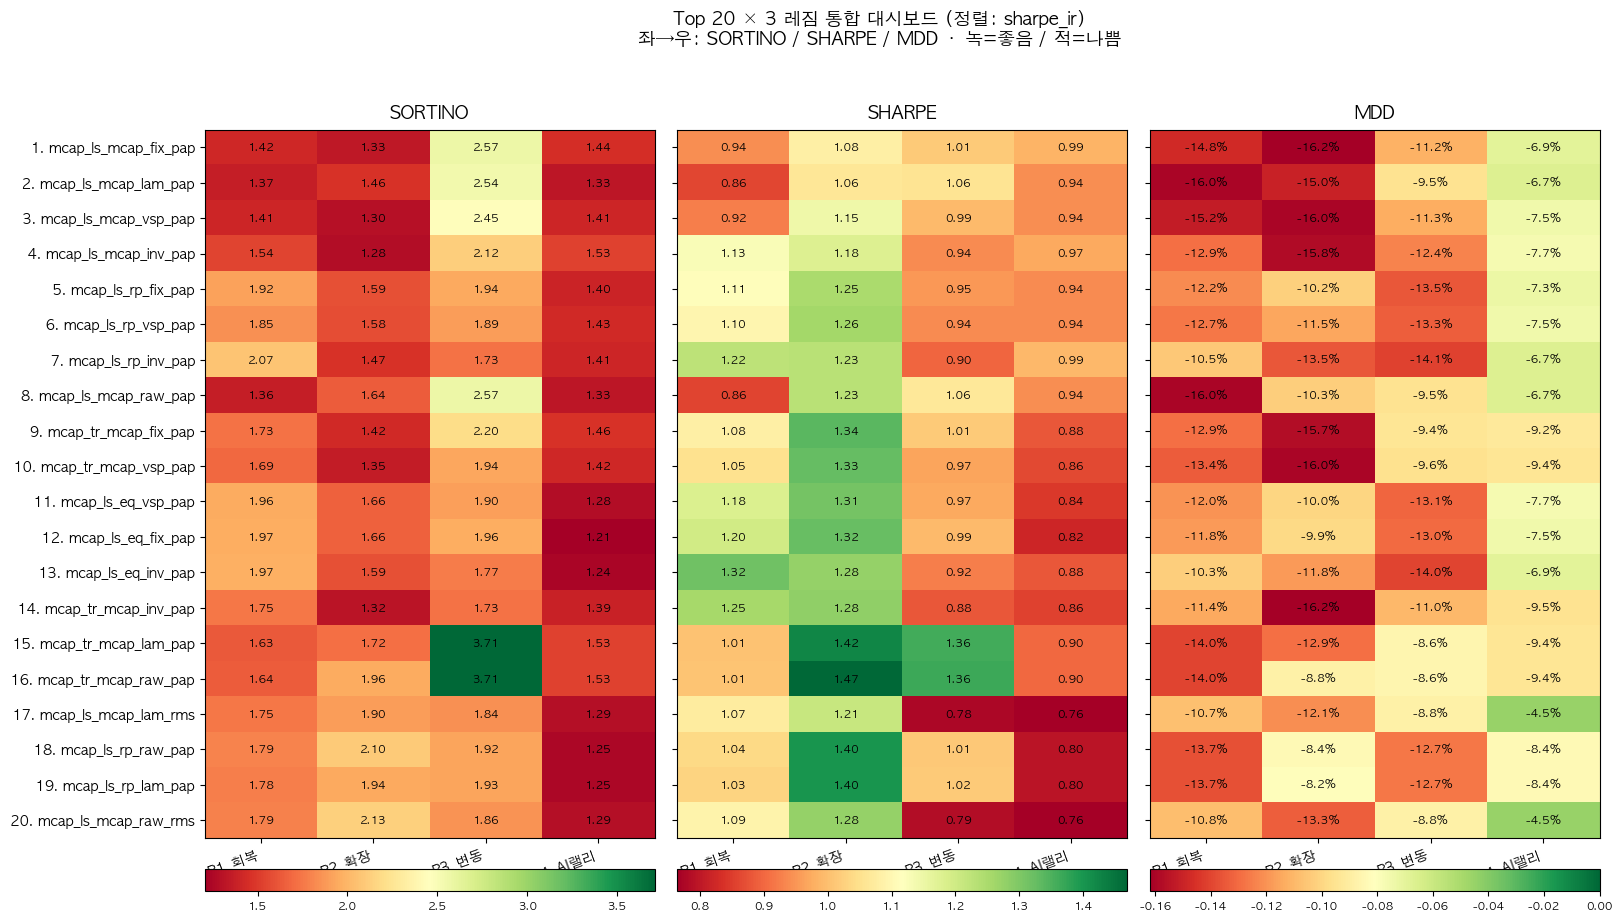

In [14]:
# ── F. sharpe_ir Top 20 dashboard (4-레짐) ────────────────
print('=== F. sharpe_ir 정렬 Top 20 (4-레짐 × 3 metric 히트맵) ===')
print('  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨')

_ = plot_styled_regime_dashboard(
    rt, rank_by='sharpe_ir', top_n=20,
    regime_labels=REGIME_LABELS_4,
    save_path=OUT_DIR / 'F_sharpe_ir_dashboard.png',
)

top20_shi = rt.nlargest(20, 'sharpe_ir').reset_index(drop=True); top20_shi.index += 1
print('\n■ Top 20 행 매핑 (sharpe_ir 큰 순)')
display(top20_shi[['canonical','sharpe_ir','sharpe_mean','sharpe_std','sharpe_full','sortino_ir','mdd_worst']].round(3))


## G. Sharpe IR ∩ sharpe_full Top 50 교집합 + Sortino 결과와 비교

Sharpe 두 측면 교집합 → Sortino 교집합과 후보가 겹치는지 점검.

■ Sharpe 교집합  (Top50 ∩): 23개
■ Sortino 교집합 (Top50 ∩): 12개

■ 두 교집합 모두 통과: 4개 (가장 robust)
■ Sharpe만 통과     : 19개
■ Sortino만 통과    : 8개

=== G-1. Sharpe 교집합 23개 — 4-레짐 히트맵 (sharpe_full 정렬) ===

■ Sharpe 교집합 행 매핑 (sharpe_full 큰 순)


,canonical,sharpe_full,sharpe_ir,sortino_full,sortino_ir,mdd_worst
1,mcap_tr_mcap_raw_pap,1.244,5.00,2.064,2.51,-0.140
2,mcap_tr_mcap_lam_pap,1.233,5.24,1.965,2.37,-0.140
3,mcap_ls_eq_lam_pap,1.156,4.19,1.819,4.82,-0.139
4,mcap_ls_eq_raw_pap,1.150,4.21,1.853,4.51,-0.139
5,mcap_ls_rp_lam_pap,1.130,4.89,1.787,6.16,-0.137
6,mcap_ls_eq_fix_pap,1.127,5.65,1.688,5.46,-0.130
7,mcap_ls_rp_raw_pap,1.125,4.90,1.818,5.57,-0.137
8,mcap_tr_mcap_fix_pap,1.121,6.50,1.617,5.47,-0.157
9,mcap_ls_eq_vsp_pap,1.113,5.98,1.680,6.34,-0.131
10,mcap_ls_eq_inv_pap,1.113,5.55,1.614,6.16,-0.140



=== G-2. Sharpe ∩ Sortino 모두 통과한 4개 후보 ===


,canonical,sharpe_full,sharpe_ir,sortino_full,sortino_ir,mdd_worst
8,mcap_ls_eq_raw_pap,1.150,4.21,1.853,4.51,-0.139
16,mcap_ls_eq_lam_pap,1.156,4.19,1.819,4.82,-0.139
17,mcap_ls_rp_raw_pap,1.125,4.90,1.818,5.57,-0.137
23,mcap_ls_rp_lam_pap,1.130,4.89,1.787,6.16,-0.137


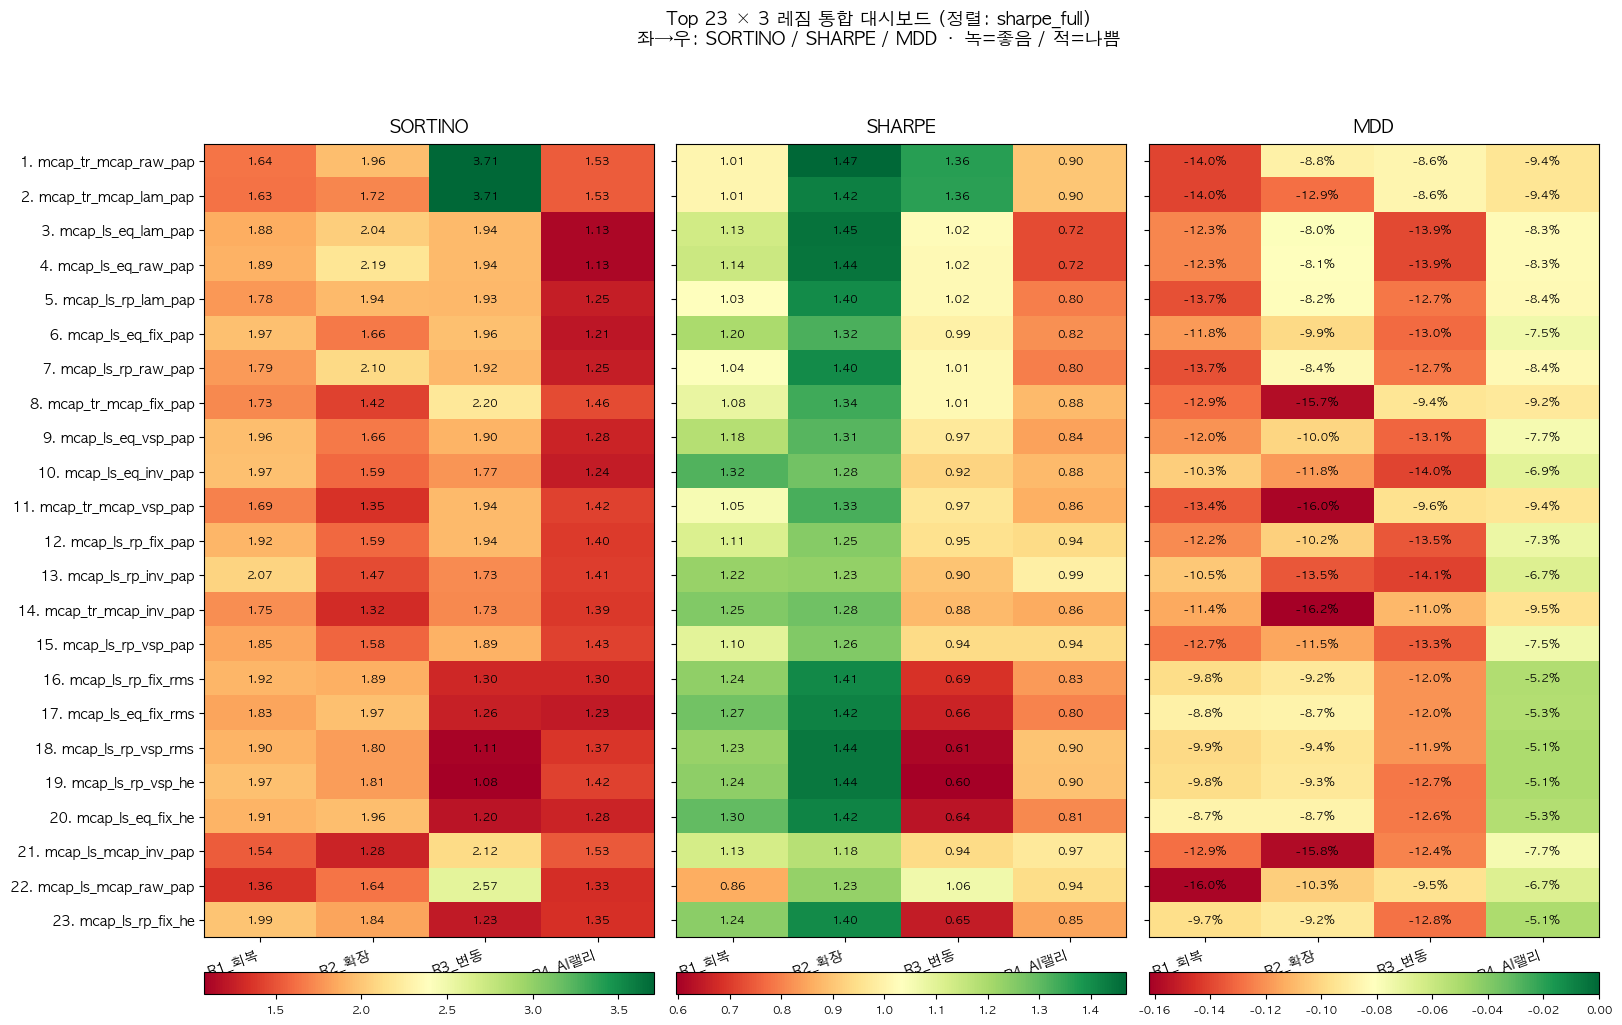

In [15]:
# ── G. Sharpe Top 50 교집합 + Sortino 교집합 비교 ─────
N = 50
top50_shf = set(rt.nlargest(N, 'sharpe_full')['name'])
top50_shi = set(rt.nlargest(N, 'sharpe_ir')['name'])
inter_sharpe = top50_shf & top50_shi

# Sortino 교집합 (앞 셀에서 만든 inter)
print(f'■ Sharpe 교집합  (Top{N} ∩): {len(inter_sharpe)}개')
print(f'■ Sortino 교집합 (Top{N} ∩): {len(inter)}개')

both = inter_sharpe & inter
sharpe_only = inter_sharpe - inter
sortino_only = inter - inter_sharpe

print(f'\n■ 두 교집합 모두 통과: {len(both)}개 (가장 robust)')
print(f'■ Sharpe만 통과     : {len(sharpe_only)}개')
print(f'■ Sortino만 통과    : {len(sortino_only)}개')

if len(inter_sharpe) > 0:
    rt_inter_sh = rt[rt['name'].isin(inter_sharpe)].copy()
    print(f'\n=== G-1. Sharpe 교집합 {len(inter_sharpe)}개 — 4-레짐 히트맵 (sharpe_full 정렬) ===')
    _ = plot_styled_regime_dashboard(
        rt_inter_sh, rank_by='sharpe_full', top_n=len(inter_sharpe),
        regime_labels=REGIME_LABELS_4,
        save_path=OUT_DIR / 'G1_sharpe_intersection_dashboard.png',
    )
    inter_sh_top = rt_inter_sh.nlargest(len(inter_sharpe), 'sharpe_full').reset_index(drop=True); inter_sh_top.index += 1
    print('\n■ Sharpe 교집합 행 매핑 (sharpe_full 큰 순)')
    display(inter_sh_top[['canonical','sharpe_full','sharpe_ir','sortino_full','sortino_ir','mdd_worst']].round(3))

# 두 교집합 모두 통과한 후보 (가장 robust)
if len(both) > 0:
    print(f'\n=== G-2. Sharpe ∩ Sortino 모두 통과한 {len(both)}개 후보 ===')
    rt_both = rt[rt['name'].isin(both)].copy()
    display(rt_both[['canonical','sharpe_full','sharpe_ir','sortino_full','sortino_ir','mdd_worst']].sort_values('sortino_full', ascending=False).round(3))
